# Práctica 2 — Generación de Variables Aleatorias Discretas
**CC2017 Modelación y Simulación — Ciclo 2, 2026**

Notebook único de solución y verificación numérica. Todas las simulaciones usan una semilla global reproducible, excepto el Ejercicio 4, que exige explícitamente la secuencia determinista de números aleatorios del texto.

## 0. Configuración común

In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, special, stats
from IPython.display import display

SEMILLA = 20_172_026
rng = np.random.default_rng(SEMILLA)

NAVY = "#003865"
ORANGE = "#FC4C02"
GREY = "#696969"
YELLOW = "#FDB92E"
PALETA = [NAVY, ORANGE, GREY, YELLOW]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def tabla(df, decimales=6):
    # Tabla uniforme, sin índice, con formato numérico homogéneo.
    return df.style.hide(axis="index").format(precision=decimales, thousands=",")


def z_desviacion(estimacion, exacto, se):
    return (estimacion - exacto) / se if se > 0 else np.nan


def se_media(x):
    x = np.asarray(x, dtype=float)
    return x.std(ddof=1) / np.sqrt(x.size)

print(f"Semilla global: {SEMILLA}")

Semilla global: 20172026


## 1. Problema 1 — Política de inventario

**Enunciado resumido.** La demanda diaria toma valores 0,1,2,3,4,5 con probabilidades 0.05, 0.15, 0.30, 0.30, 0.15, 0.05. La tienda tiene capacidad limitada y comienza cada día con hasta tres botellas disponibles.

**Método.** Se interpreta correctamente como una política **order-up-to** de capacidad $C$: las botellas sobrantes permanecen en inventario y cada mañana se compra únicamente lo necesario para volver a $C$. No hay desperdicio ni caducidad en el enunciado. Se simulan 15 días y luego 10,000 réplicas de 15 días, usando números aleatorios comunes para comparar $C=1,\ldots,5$.

In [2]:
demandas = np.arange(6)
prob_demanda = np.array([0.05, 0.15, 0.30, 0.30, 0.15, 0.05])
cdf_demanda = np.round(np.cumsum(prob_demanda), 12)

assert np.isclose(prob_demanda.sum(), 1.0)
assert cdf_demanda[4] == 0.95  # evita 0.9500000000000001


def demanda_desde_u(u):
    u = np.asarray(u)
    return np.searchsorted(cdf_demanda, u, side="left")

# Pruebas explícitas de fronteras de los intervalos.
u_fronteras = np.array([0.00, 0.05, 0.050000000001, 0.20, 0.50, 0.80, 0.95, 0.950000000001, 0.999999999999])
esperado = np.array([0, 0, 1, 1, 2, 3, 4, 5, 5])
obtenido = demanda_desde_u(u_fronteras)
assert np.array_equal(obtenido, esperado)

pd.DataFrame({"U": u_fronteras, "Demanda": obtenido})

,U,Demanda
0,0.00,0
1,0.05,0
2,0.05,1
3,0.20,1
4,0.50,2
5,0.80,3
6,0.95,4
7,0.95,5
8,1.00,5


In [3]:
def simular_15_dias(C, u):
    d = demanda_desde_u(u)
    n = len(d)
    apertura = np.empty(n, dtype=int)
    compra = np.empty(n, dtype=int)
    vendidas = np.minimum(d, C)
    finales = C - vendidas
    perdidas = np.maximum(d - C, 0)

    apertura[0] = C       # inventario comprado antes del horizonte
    compra[0] = 0
    for t in range(1, n):
        apertura[t] = finales[t-1]
        compra[t] = C - apertura[t]

    # Contabilidad diaria real: stock al abrir + compra = ventas + inventario final.
    assert np.array_equal(apertura + compra, vendidas + finales)
    assert np.all(apertura + compra == C)
    assert np.array_equal(compra[1:], vendidas[:-1])  # la reposición es endógena: repone lo vendido

    return pd.DataFrame({
        "Día": np.arange(1, n+1),
        "U": u,
        "Inventario al abrir": apertura,
        "Compradas": compra,
        "Demanda": d,
        "Vendidas": vendidas,
        "Ventas perdidas": perdidas,
        "Inventario final": finales,
        "Resultado": np.where(perdidas > 0, "Venta perdida", np.where(finales > 0, "Sobrante", "Exacto"))
    })

u_15 = rng.random(15)
detalle_15 = simular_15_dias(3, u_15)
display(tabla(detalle_15, 4))

Día,U,Inventario al abrir,Compradas,Demanda,Vendidas,Ventas perdidas,Inventario final,Resultado
1,0.6280,3,0,3,3,0,0,Exacto
2,0.1341,0,3,1,1,0,2,Sobrante
3,0.7820,2,1,3,3,0,0,Exacto
4,0.5056,0,3,3,3,0,0,Exacto
5,0.7969,0,3,3,3,0,0,Exacto
6,0.7206,0,3,3,3,0,0,Exacto
7,0.9433,0,3,4,3,1,0,Venta perdida
8,0.6425,0,3,3,3,0,0,Exacto
9,0.0289,0,3,0,0,0,3,Sobrante
10,0.3836,3,0,2,2,0,1,Sobrante


In [4]:
# Valores exactos por día para una capacidad C.
ED = np.dot(demandas, prob_demanda)

def exactos_capacidad(C):
    vend = np.minimum(demandas, C)
    perd = np.maximum(demandas - C, 0)
    sobr = C - vend
    return {
        "demanda": ED,
        "vendidas": np.dot(vend, prob_demanda),
        "perdidas": np.dot(perd, prob_demanda),
        "sobrante": np.dot(sobr, prob_demanda),
        "servicio": np.dot(vend, prob_demanda) / ED,
        "stockout": prob_demanda[demandas > C].sum(),
    }

# 10,000 réplicas x 15 días; los mismos U se usan para todas las capacidades.
R, H = 10_000, 15
u_comun = rng.random((R, H))
demanda_comun = demanda_desde_u(u_comun)

filas = []
for C in range(1, 6):
    vend = np.minimum(demanda_comun, C)
    perd = np.maximum(demanda_comun - C, 0)
    sobr = C - vend
    stockout = (demanda_comun > C).astype(float)

    # Medias por réplica, útiles para SE de medias diarias.
    vend_rep = vend.mean(axis=1)
    perd_rep = perd.mean(axis=1)
    sobr_rep = sobr.mean(axis=1)
    stockout_rep = stockout.mean(axis=1)

    # Nivel de servicio = ventas totales / demanda total. SE por delta method sobre totales por réplica.
    A = vend.sum(axis=1).astype(float)
    B = demanda_comun.sum(axis=1).astype(float)
    servicio_hat = A.sum() / B.sum()
    a_bar, b_bar = A.mean(), B.mean()
    g = A - servicio_hat * B
    se_servicio = g.std(ddof=1) / np.sqrt(R) / b_bar

    ex = exactos_capacidad(C)
    filas.append({
        "C": C,
        "Servicio MC": servicio_hat,
        "SE servicio": se_servicio,
        "Servicio exacto": ex["servicio"],
        "z servicio": z_desviacion(servicio_hat, ex["servicio"], se_servicio),
        "Perdidas/día MC": perd_rep.mean(),
        "SE pérdidas": se_media(perd_rep),
        "Pérdidas exactas": ex["perdidas"],
        "z pérdidas": z_desviacion(perd_rep.mean(), ex["perdidas"], se_media(perd_rep)),
    })

barrido = pd.DataFrame(filas)
display(tabla(barrido, 6))

C,Servicio MC,SE servicio,Servicio exacto,z servicio,Perdidas/día MC,SE pérdidas,Pérdidas exactas,z pérdidas
1,0.379456,0.000415,0.380000,-1.310380,1.552527,0.002897,1.550000,0.872274
2,0.699104,0.000593,0.700000,-1.510722,0.752807,0.002294,0.750000,1.223374
3,0.899851,0.000468,0.900000,-0.318021,0.250560,0.001382,0.250000,0.405317
4,0.979863,0.000215,0.980000,-0.637266,0.050380,0.000565,0.050000,0.672832
5,1.000000,0.000000,1.000000,nan,0.000000,0.000000,0.000000,nan


In [5]:
# Resumen específico C=3, incluyendo todas las métricas solicitadas para la decisión.
C = 3
vend = np.minimum(demanda_comun, C)
perd = np.maximum(demanda_comun - C, 0)
sobr = C - vend
stock = (demanda_comun > C).astype(float)
metricas = {
    "Demanda/día": demanda_comun.mean(axis=1),
    "Vendidas/día": vend.mean(axis=1),
    "Perdidas/día": perd.mean(axis=1),
    "Sobrante final/día": sobr.mean(axis=1),
    "P(stockout)": stock.mean(axis=1),
}
exactos3 = exactos_capacidad(3)
exact_map = {
    "Demanda/día": exactos3["demanda"],
    "Vendidas/día": exactos3["vendidas"],
    "Perdidas/día": exactos3["perdidas"],
    "Sobrante final/día": exactos3["sobrante"],
    "P(stockout)": exactos3["stockout"],
}
res3=[]
for nombre, vals in metricas.items():
    est=vals.mean(); se=se_media(vals); ex=exact_map[nombre]
    res3.append({"Métrica":nombre,"Estimación MC":est,"SE":se,"Exacto":ex,"Desviación (SE)":z_desviacion(est,ex,se)})

# Servicio por separado (razón de totales).
A=vend.sum(axis=1).astype(float); B=demanda_comun.sum(axis=1).astype(float)
serv=A.sum()/B.sum(); g=A-serv*B; se_serv=g.std(ddof=1)/np.sqrt(R)/B.mean()
res3.append({"Métrica":"Nivel de servicio","Estimación MC":serv,"SE":se_serv,"Exacto":exactos3["servicio"],"Desviación (SE)":z_desviacion(serv,exactos3["servicio"],se_serv)})
res3=pd.DataFrame(res3)
display(tabla(res3,6))

Métrica,Estimación MC,SE,Exacto,Desviación (SE)
Demanda/día,2.501880,0.003128,2.500000,0.601106
Vendidas/día,2.251320,0.002305,2.250000,0.572690
Perdidas/día,0.250560,0.001382,0.250000,0.405317
Sobrante final/día,0.748680,0.002305,0.750000,-0.572690
P(stockout),0.200180,0.001028,0.200000,0.175121
Nivel de servicio,0.899851,0.000468,0.900000,-0.318021


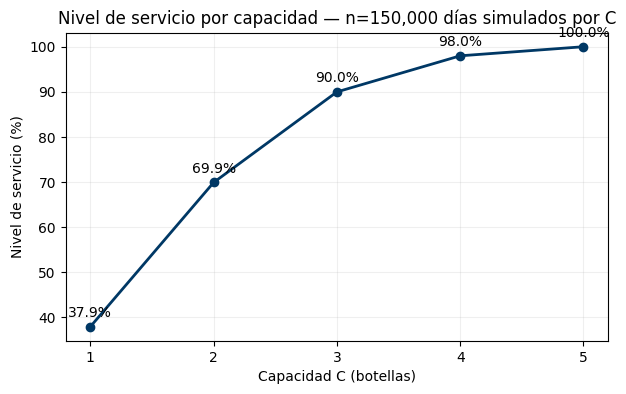

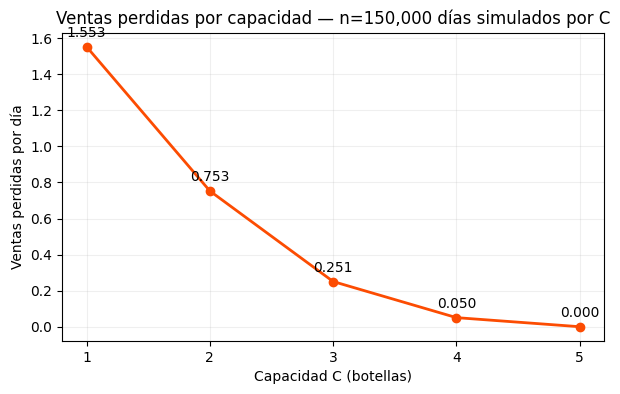

In [6]:
# Gráficos del barrido de capacidad.
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(barrido["C"], 100*barrido["Servicio MC"], marker="o", linewidth=2, color=NAVY)
for x,y in zip(barrido["C"], 100*barrido["Servicio MC"]):
    ax.annotate(f"{y:.1f}%", (x,y), xytext=(0,7), textcoords="offset points", ha="center")
ax.set_xlabel("Capacidad C (botellas)")
ax.set_ylabel("Nivel de servicio (%)")
ax.set_title(f"Nivel de servicio por capacidad — n={R*H:,} días simulados por C")
ax.set_xticks(range(1,6)); ax.grid(alpha=.2)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(barrido["C"], barrido["Perdidas/día MC"], marker="o", linewidth=2, color=ORANGE)
for x,y in zip(barrido["C"], barrido["Perdidas/día MC"]):
    ax.annotate(f"{y:.3f}", (x,y), xytext=(0,7), textcoords="offset points", ha="center")
ax.set_xlabel("Capacidad C (botellas)")
ax.set_ylabel("Ventas perdidas por día")
ax.set_title(f"Ventas perdidas por capacidad — n={R*H:,} días simulados por C")
ax.set_xticks(range(1,6)); ax.grid(alpha=.2)
plt.show()

### Respuesta

**No: abastecer hasta una capacidad de 3 botellas no es adecuado si existe la posibilidad de ampliar capacidad.** Exactamente, $C=3$ atiende el **90%** de la demanda, pierde **0.25 botellas/día** y presenta $P(D>3)=\mathbf{0.20}$; pasar a $C=4$ eleva el servicio a **98%** y reduce las pérdidas a **0.05/día**, y $C=5$ elimina las ventas perdidas bajo esta distribución.

La conclusión sólo se invertiría si ampliar el espacio tuviera un costo marginal superior al valor económico de las ventas recuperadas. No hay costo por desperdicio: los sobrantes permanecen en inventario. Un modelo newsvendor sería pertinente únicamente si los sobrantes se descartaran, condición que el enunciado no establece.

## 2. Ejercicio 2

**Método.** Como todas las probabilidades son múltiplos de 0.05, se usa una tabla de 20 entradas: un solo $U$, una conversión directa a índice y cero comparaciones probabilísticas. Como alternativa, transformación inversa; ordenar por probabilidad decreciente reduce el número esperado de comparaciones.

In [7]:
valores2 = np.array([1,2,3,4])
p2 = np.array([0.30,0.20,0.35,0.15])
lookup20 = np.array([1]*6 + [2]*4 + [3]*7 + [4]*3)
assert len(lookup20)==20
assert np.array_equal(np.bincount(lookup20, minlength=5)[1:]/20, p2)


def generar_lookup(u):
    k = np.minimum((20*np.asarray(u)).astype(int), 19)
    return lookup20[k]

# Transformación inversa como fallback, permitiendo ordenar categorías.
def inversa_ordenada(u, orden):
    probs = np.array([p2[v-1] for v in orden])
    cdf = np.round(np.cumsum(probs), 12)
    return np.array(orden)[np.searchsorted(cdf, np.asarray(u), side="left")]

orden_prob = [3,1,2,4]
orden_natural = [1,2,3,4]
Ecomp_prob = sum((k+1)*p2[v-1] for k,v in enumerate(orden_prob))
Ecomp_nat = sum((k+1)*p2[v-1] for k,v in enumerate(orden_natural))

res2 = pd.DataFrame({
    "Método":["Lookup 20","Inversa orden 3,1,2,4","Inversa orden 1,2,3,4"],
    "U por variable":[1,1,1],
    "Comparaciones esperadas":[0,Ecomp_prob,Ecomp_nat],
    "Complejidad":["O(1)","O(k)","O(k)"]
})
display(tabla(res2,3))

Método,U por variable,Comparaciones esperadas,Complejidad
Lookup 20,1,0.000,O(1)
"Inversa orden 3,1,2,4",1,2.150,O(k)
"Inversa orden 1,2,3,4",1,2.350,O(k)


### Respuesta

Lookup: $k=\lfloor20U\rfloor$ y `tabla[k]`, con tabla `[1×6, 2×4, 3×7, 4×3]`; usa **1 U, 0 comparaciones, O(1)**. Fallback inverso: comparar acumuladas en orden $(3,1,2,4)$; $E[C]=0.35(1)+0.30(2)+0.20(3)+0.15(4)=\mathbf{2.15}$. En orden natural $(1,2,3,4)$, $E[C]=\mathbf{2.35}$.

## 3. Ejercicio 3

Sea $N=\sum_{i=1}^{100}I_i$, donde $I_i=1$ si la carta $i$ aparece en la posición $i$. Entonces $P(I_i=1)=1/100$.

$$E[N]=\sum_i E[I_i]=100\left(\frac1{100}\right)=1.$$

Para $i\ne j$, $P(I_i=I_j=1)=1/(100\cdot99)$, por lo que
$$\operatorname{Cov}(I_i,I_j)=\frac1{100\cdot99}-\frac1{100^2}.$$
Así,
$$\operatorname{Var}(N)=100\frac1{100}\frac{99}{100}+2\binom{100}{2}\left(\frac1{100\cdot99}-\frac1{100^2}\right)=\mathbf1.$$

Se simulan permutaciones y se compara la distribución de puntos fijos con Poisson(1), aproximación prácticamente indistinguible para $n=100$.

Cantidad,Estimación MC,SE,Exacto,Desviación (SE)
E[N],1.003260,0.003168,1.000000,1.029155
Var(N),1.003399,0.005606,1.000000,0.606415


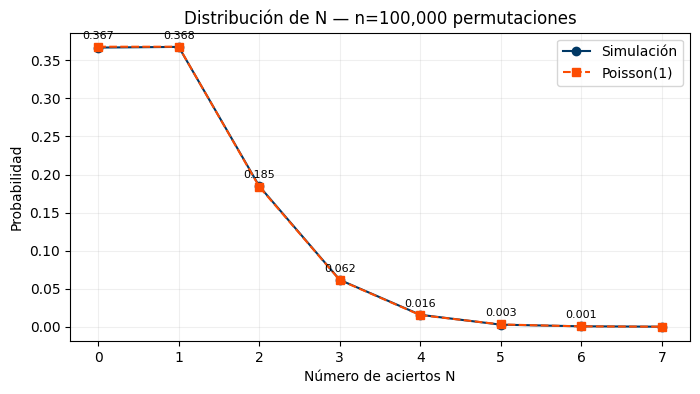

In [8]:
R3 = 100_000
aciertos = np.empty(R3, dtype=np.int16)
base = np.arange(100)
for r in range(R3):
    aciertos[r] = np.count_nonzero(rng.permutation(100) == base)

media3 = aciertos.mean(); se_m3 = se_media(aciertos)
# SE de la varianza por lotes independientes.
B3 = 200
vars_lote = np.array([x.var(ddof=1) for x in np.array_split(aciertos, B3)])
var3 = aciertos.var(ddof=1); se_v3 = vars_lote.std(ddof=1)/np.sqrt(B3)

res3e = pd.DataFrame([
    {"Cantidad":"E[N]","Estimación MC":media3,"SE":se_m3,"Exacto":1.0,"Desviación (SE)":z_desviacion(media3,1,se_m3)},
    {"Cantidad":"Var(N)","Estimación MC":var3,"SE":se_v3,"Exacto":1.0,"Desviación (SE)":z_desviacion(var3,1,se_v3)},
])
display(tabla(res3e,6))

kmax = max(7, int(aciertos.max()))
k = np.arange(kmax+1)
pmf_emp = np.array([(aciertos==j).mean() for j in k])
pmf_poi = stats.poisson.pmf(k,1)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(k, pmf_emp, marker="o", label="Simulación", color=NAVY)
ax.plot(k, pmf_poi, marker="s", linestyle="--", label="Poisson(1)", color=ORANGE)
for x,y in zip(k[:7], pmf_emp[:7]):
    ax.annotate(f"{y:.3f}", (x,y), xytext=(0,6), textcoords="offset points", ha="center", fontsize=8)
ax.set_xlabel("Número de aciertos N")
ax.set_ylabel("Probabilidad")
ax.set_title(f"Distribución de N — n={R3:,} permutaciones")
ax.legend(); ax.grid(alpha=.2)
plt.show()

### Respuesta

$\boxed{E[N]=1}$ y $\boxed{\operatorname{Var}(N)=1}$ exactamente. La simulación reproduce ambos valores dentro del error Monte Carlo y la pmf empírica coincide, a escala gráfica, con Poisson(1).

## 4. Ejercicio 4

**Método eficiente.** Como $p=0.8>1/2$, se generan directamente las posiciones de los **fracasos** (probabilidad $q=0.2$) mediante saltos geométricos. El texto define su secuencia por $x_1=23$, $x_2=66$, $x_n=(3x_{n-1}+5x_{n-2})\bmod100$, $u_n=x_n/100$.

Si $M$ es el número de uniformes usados, cada cero requiere un uniforme y se necesita un uniforme adicional exactamente cuando la observación 25 es éxito. Por tanto
$$E[M]=25(0.2)+P(X_{25}=1)=5+0.8=\mathbf{5.8}.$$

In [9]:
def secuencia_texto(m):
    xs = [23,66]
    while len(xs) < m:
        xs.append((3*xs[-1] + 5*xs[-2]) % 100)
    return np.array(xs, dtype=float)/100

u_texto = secuencia_texto(100)
x_bern = np.ones(25, dtype=int)
pos = 0; usados = []
while pos < 25:
    U = u_texto[len(usados)]
    usados.append(U)
    salto = int(np.floor(np.log(U)/np.log(0.8))) + 1  # Geom(q=.2)
    pos += salto
    if pos <= 25:
        x_bern[pos-1] = 0

assert len(x_bern)==25
assert set(np.unique(x_bern)).issubset({0,1})
res4 = pd.DataFrame({"Posición":np.arange(1,26),"Bernoulli":x_bern})
display(tabla(res4,0))
print("U usados:", np.array(usados))
print("Número real de U usados:", len(usados))
print("Número esperado exacto de U:", 25*0.2 + 0.8)

Posición,Bernoulli
1,1
2,1
3,1
4,1
5,1
6,1
7,0
8,1
9,0
10,1


U usados: [0.23 0.66 0.13 0.69 0.72 0.61]
Número real de U usados: 6
Número esperado exacto de U: 5.8


### Respuesta

Secuencia obtenida: `1111110101111111110101011`. Se usaron **6 números aleatorios**: $0.23,0.66,0.13,0.69,0.72,0.61$. El número esperado exacto es $\boxed{5.8}$, frente a 25 uniformes con el método ingenuo.

## 5. Ejercicio 5

**Exacto.** Para los 11 cupones (sumas 2,...,12), con probabilidades $p_i=(1,2,3,4,5,6,5,4,3,2,1)/36$, el tiempo hasta observarlos todos cumple la fórmula de inclusión–exclusión
$$E[T]=\sum_{\emptyset\ne A\subseteq\{1,\ldots,11\}}(-1)^{|A|+1}\frac{1}{\sum_{i\in A}p_i},$$
que requiere $2^{11}-1=2047$ términos. La simulación se ejecuta sin tope artificial de lanzamientos.

In [10]:
p_sumas = np.array([1,2,3,4,5,6,5,4,3,2,1], dtype=float)/36
ET_exacto = 0.0
terminos = 0
for mask in range(1, 1<<11):
    idx = [i for i in range(11) if (mask>>i)&1]
    ET_exacto += ((-1)**(len(idx)+1)) / p_sumas[idx].sum()
    terminos += 1
assert terminos == 2**11-1

R5 = 100_000
vistos = np.zeros((R5,11), dtype=bool)
T = np.zeros(R5, dtype=np.int16)
pendientes = np.arange(R5)
while pendientes.size:
    # Un "lanzamiento" = un par de dados.
    suma = rng.integers(1,7,size=pendientes.size) + rng.integers(1,7,size=pendientes.size)
    T[pendientes] += 1
    vistos[pendientes, suma-2] = True
    pendientes = pendientes[~vistos[pendientes].all(axis=1)]

est5=T.mean(); se5=se_media(T)
res5=pd.DataFrame([{"Estimación MC":est5,"SE":se5,"Exacto inclusión-exclusión":ET_exacto,"Desviación (SE)":z_desviacion(est5,ET_exacto,se5),"Máximo T observado":int(T.max()),"Réplicas truncadas":0}])
display(tabla(res5,6))

Estimación MC,SE,Exacto inclusión-exclusión,Desviación (SE),Máximo T observado,Réplicas truncadas
61.308420,0.114038,61.217385,0.798287,381,0


### Respuesta

$$\boxed{E[T]=61.21738476395717}.$$
La simulación usa 100,000 réplicas, sin truncamiento; su estimación, SE y desviación estandarizada aparecen arriba.

## 6. Ejercicio 6

Sea una lista de longitud $n$ y sea $F$ el conjunto de posiciones que son la **primera aparición** de cada elemento distinto. Si $J\sim\text{Uniforme}\{1,\ldots,n\}$, defina
$$Z=n\,v(J)\,\mathbf 1\{J\in F\}.$$
Como hay exactamente una primera aparición por elemento distinto,
$$E[Z]=\frac1n\sum_{j=1}^n n\,v(j)\mathbf 1\{j\in F\}=\sum_{a\text{ distinto}}v(a).$$
Por tanto, la media de $r$ copias de $Z$ es un estimador insesgado de la suma buscada.

r,Estimación,SE,Exacto,Desviación (SE)
100,18.86000,8.94135,24.00000,-0.57486
"1,000",28.12600,4.01192,24.00000,1.02843
"10,000",25.46920,1.19522,24.00000,1.22923
"50,000",23.84068,0.51615,24.00000,-0.30867
"200,000",23.98664,0.25810,24.00000,-0.05176


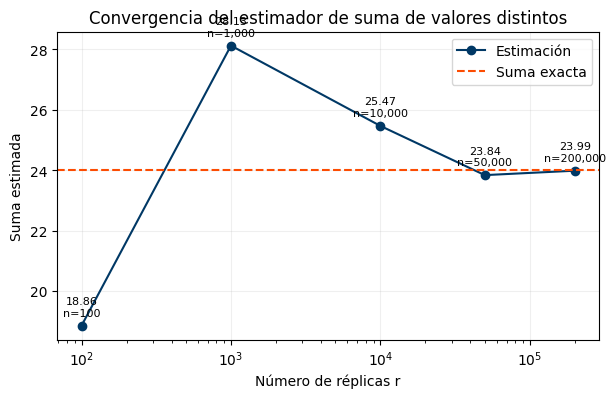

In [11]:
# Lista sintética con repeticiones fuertemente desiguales.
elementos = np.array(list("A")*1 + list("B")*3 + list("C")*8 + list("D")*20 + list("E")*50)
valor = {"A":10.0,"B":7.0,"C":4.0,"D":2.0,"E":1.0}
n6=len(elementos)

# Identificar primeras apariciones.
vistos_set=set(); primera=np.zeros(n6,dtype=bool)
for i,a in enumerate(elementos):
    if a not in vistos_set:
        primera[i]=True; vistos_set.add(a)

suma_exacta=sum(valor[a] for a in sorted(set(elementos)))
assert primera.sum()==len(set(elementos))
assert suma_exacta==24.0

r_max=200_000
J=rng.integers(0,n6,size=r_max)
Z=np.where(primera[J], n6*np.array([valor[a] for a in elementos[J]]), 0.0)

filas=[]
for r in [100,1_000,10_000,50_000,200_000]:
    z=Z[:r]; est=z.mean(); se=se_media(z)
    filas.append({"r":r,"Estimación":est,"SE":se,"Exacto":suma_exacta,"Desviación (SE)":z_desviacion(est,suma_exacta,se)})
conv6=pd.DataFrame(filas)
display(tabla(conv6,5))

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(conv6["r"],conv6["Estimación"],marker="o",label="Estimación", color=NAVY)
ax.axhline(suma_exacta,linestyle="--",label="Suma exacta", color=ORANGE)
for x,y in zip(conv6["r"],conv6["Estimación"]):
    ax.annotate(f"{y:.2f}\nn={x:,}",(x,y),xytext=(0,7),textcoords="offset points",ha="center",fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("Número de réplicas r"); ax.set_ylabel("Suma estimada")
ax.set_title("Convergencia del estimador de suma de valores distintos"); ax.legend(); ax.grid(alpha=.2)
plt.show()

### Respuesta

Estimador: $\hat S_r=r^{-1}\sum_{k=1}^r n\,v(J_k)\mathbf1\{J_k\text{ es primera aparición}\}$. Es insesgado y converge a la suma exacta. En el ejemplo, $\boxed{S=24}$.

## 7. Ejercicio 7

En el Paso 2,
$$Y=\left\lfloor\frac{\log U}{\log(1-\lambda)}\right\rfloor+1$$
tiene distribución geométrica sobre $\{1,2,\ldots\}$ con parámetro $\lambda$:
$$P(Y=k)=(1-\lambda)^{k-1}\lambda.$$

El algoritmo genera tiempos candidatos de un proceso geométrico con hazard constante $\lambda$ y acepta un candidato $S$ con probabilidad $\lambda_S/\lambda$ (thinning). Para llegar vivo a $n$ deben rechazarse los riesgos previos, y luego aceptarse $n$, por lo que
$$p_n=P(X=n)=\lambda_n\prod_{i<n}(1-\lambda_i),\qquad P(X=n\mid X\ge n)=\lambda_n.$$

In [12]:
LAM_SUP = 0.55

def hazard(n):
    n=np.asarray(n,dtype=float)
    # Secuencia concreta, positiva, variable y estrictamente menor que LAM_SUP y que 1.
    return 0.10 + 0.34*(1-np.exp(-n/8.0))

assert np.max(hazard(np.arange(1,10_001))) < LAM_SUP
assert np.max(hazard(np.arange(1,10_001))) < 1.0


def generar_hazard():
    # PASO 1: S = 0.
    S = 0
    while True:
        # PASO 2: Genere U y haga Y = Int(log(U)/log(1-lambda)) + 1.
        U = rng.random()
        Y = int(np.floor(np.log(U)/np.log(1-LAM_SUP))) + 1
        # PASO 3: S = S + Y.
        S = S + Y
        # PASO 4: Genere U.
        U = rng.random()
        # PASO 5: Si U <= lambda_S/lambda, X=S y deténgase; si no, vuelva al Paso 2.
        if U <= hazard(S)/LAM_SUP:
            return S

R7=120_000
X7=np.fromiter((generar_hazard() for _ in range(R7)),dtype=np.int32,count=R7)

nvals=np.arange(1,13)
lam=hazard(nvals)
surv_prev=np.r_[1.0,np.cumprod(1-hazard(np.arange(1,12)))]
pmf_exact=lam*surv_prev
filas=[]
for n,l,pe in zip(nvals,lam,pmf_exact):
    risk=np.count_nonzero(X7>=n); event=np.count_nonzero(X7==n)
    hhat=event/risk; seh=np.sqrt(hhat*(1-hhat)/risk)
    phat=event/R7; sep=np.sqrt(phat*(1-phat)/R7)
    filas.append({"n":n,"lambda_n":l,"Hazard MC":hhat,"SE hazard":seh,"z hazard":z_desviacion(hhat,l,seh),"pmf MC":phat,"SE pmf":sep,"pmf exacta":pe,"z pmf":z_desviacion(phat,pe,sep)})
res7=pd.DataFrame(filas)
display(tabla(res7,6))

n,lambda_n,Hazard MC,SE hazard,z hazard,pmf MC,SE pmf,pmf exacta,z pmf
1,0.139951,0.140617,0.001004,0.663286,0.140617,0.001004,0.139951,0.663286
2,0.175208,0.175562,0.001185,0.298978,0.150875,0.001033,0.150687,0.181731
3,0.206322,0.208325,0.001393,1.438392,0.147600,0.001024,0.146357,1.214254
4,0.233780,0.236283,0.001637,1.529182,0.132533,0.000979,0.131619,0.934046
5,0.258011,0.257076,0.001928,-0.485054,0.110125,0.000904,0.111302,-1.302858
6,0.279395,0.281985,0.002303,1.124608,0.089742,0.000825,0.089430,0.377901
7,0.298267,0.295978,0.002757,-0.830494,0.067633,0.000725,0.068796,-1.604394
8,0.314921,0.315929,0.003346,0.301124,0.050825,0.000634,0.050972,-0.232278
9,0.329618,0.334772,0.004107,1.255055,0.036842,0.000544,0.036550,0.536855
10,0.342588,0.344109,0.005069,0.300061,0.025192,0.000452,0.025466,-0.607363


### Respuesta

$Y\sim\operatorname{Geom}(\lambda)$ en $\{1,2,\ldots\}$. El algoritmo hace thinning de tiempos candidatos geométricos. Se verifica numéricamente que $\boxed{P(X=n\mid X\ge n)=\lambda_n}$ y $\boxed{p_n=\lambda_n\prod_{i<n}(1-\lambda_i)}$.

## 8. Ejercicio 8

En cada pasada se genera $X=i$ y se acepta con probabilidad $P(Y=j\mid X=i)$. Entonces
$$P(\text{aceptar y }X=i)=P(X=i)P(Y=j\mid X=i)=P(X=i,Y=j).$$
Condicionando en que una pasada fue aceptada,
$$P(W=i)=\frac{P(X=i,Y=j)}{P(Y=j)}=P(X=i\mid Y=j).$$
La probabilidad de aceptación en cada pasada es $P(Y=j)$, así que el número de pasadas es geométrico y su media exacta es $1/P(Y=j)$.

In [13]:
# Distribución conjunta concreta: filas X=0,1,2; columnas Y=0,1.
joint=np.array([[0.10,0.05],[0.20,0.15],[0.10,0.40]])
assert np.isclose(joint.sum(),1)
xvals=np.arange(3); j=1
px=joint.sum(axis=1); pyj=joint[:,j].sum(); pyj_given_x=joint[:,j]/px
cond_exact=joint[:,j]/pyj
assert np.all(pyj_given_x<=1)

R8=120_000
W=np.full(R8,-1,dtype=int); pasadas=np.zeros(R8,dtype=int)
pend=np.arange(R8)
while pend.size:
    pasadas[pend]+=1
    x=rng.choice(xvals,size=pend.size,p=px)
    u=rng.random(pend.size)
    acepta=u < pyj_given_x[x]
    W[pend[acepta]]=x[acepta]
    pend=pend[~acepta]
assert np.all(W>=0)

filas=[]
for i,p_exact in zip(xvals,cond_exact):
    ph=(W==i).mean(); se=np.sqrt(ph*(1-ph)/R8)
    filas.append({"i":i,"P(W=i) MC":ph,"SE":se,"P(X=i|Y=1) exacta":p_exact,"Desviación (SE)":z_desviacion(ph,p_exact,se)})
res8=pd.DataFrame(filas)
display(tabla(res8,6))

mp=pasadas.mean(); sep=se_media(pasadas); exactp=1/pyj
res8p=pd.DataFrame([{"Pasadas medias MC":mp,"SE":sep,"Exacto 1/P(Y=1)":exactp,"Desviación (SE)":z_desviacion(mp,exactp,sep)}])
display(tabla(res8p,6))

i,P(W=i) MC,SE,P(X=i|Y=1) exacta,Desviación (SE)
0,0.082058,0.000792,0.083333,-1.609281
1,0.251025,0.001252,0.250000,0.818884
2,0.666917,0.001361,0.666667,0.183746


Pasadas medias MC,SE,Exacto 1/P(Y=1),Desviación (SE)
1.666025,0.003041,1.666667,-0.211001


### Respuesta

El algoritmo genera exactamente $\boxed{W\sim X\mid Y=j}$. En la distribución concreta usada, $P(Y=1)=0.60$, por lo que $E[\text{pasadas}]=\boxed{1/0.60=1.6666667}$; la pmf exacta de $W$ es $(1/12,\,1/4,\,2/3)$.

## 9. Ejercicio 9 — Integrales por Monte Carlo

Se lleva cada dominio a $(0,1)$:

- (3), (4): $x=u$.
- (5): $x=4u-2$, $dx=4\,du$.
- (6): $x=u/(1-u)$, $dx=du/(1-u)^2$.
- (7): $x=\tan(\pi(u-1/2))$, $dx=\pi\sec^2(\pi(u-1/2))\,du$.
- (8): $x=u,\ y=v$.
- (9): extender a $(0,\infty)^2$ con $I_y(x)=\mathbf1\{y<x\}$ y usar $x=-\log(1-u)$, $y=-\log(1-v)$. El jacobiano cancela $e^{-(x+y)}$ y queda simplemente $\mathbf1\{v<u\}$.

Para cada integral se reporta estimación MC, error estándar, cuadratura de alta precisión y desviación en unidades de SE. Cuando existe forma cerrada se calcula además y se comprueba contra cuadratura.

In [14]:
N9=500_000

def resumen_mc(nombre, muestras, quad, cerrado=np.nan):
    est=np.mean(muestras); se=se_media(muestras)
    return {"Integral":nombre,"MC":est,"SE":se,"Cuadratura":quad,"Cerrado":cerrado,"|cerrado-quad|":abs(cerrado-quad) if np.isfinite(cerrado) else np.nan,"Desviación (SE)":z_desviacion(est,quad,se)}

filas=[]

# (3)
u=rng.random(N9); g=np.exp(np.exp(u))
q3=integrate.quad(lambda x: np.exp(np.exp(x)),0,1,epsabs=1e-12,epsrel=1e-12)[0]
c3=special.expi(math.e)-special.expi(1.0)
filas.append(resumen_mc("3",g,q3,c3))

# (4)
u=rng.random(N9); g=(1-u*u)**1.5
q4=integrate.quad(lambda x:(1-x*x)**1.5,0,1,epsabs=1e-12,epsrel=1e-12)[0]
c4=3*math.pi/16
filas.append(resumen_mc("4",g,q4,c4))

# (5)
u=rng.random(N9); x=4*u-2; g=4*np.exp(x+x*x)
q5=integrate.quad(lambda x:np.exp(x+x*x),-2,2,epsabs=1e-11,epsrel=1e-12)[0]
c5=math.exp(-0.25)*math.sqrt(math.pi)/2*(special.erfi(2.5)-special.erfi(-1.5))
filas.append(resumen_mc("5",g,q5,c5))

# (6)
u=rng.random(N9); u=np.clip(u,1e-15,1-1e-15); x=u/(1-u); g=x*(1+x*x)**-2/(1-u)**2
q6=integrate.quad(lambda x:x*(1+x*x)**-2,0,np.inf,epsabs=1e-12,epsrel=1e-12)[0]
c6=0.5
filas.append(resumen_mc("6",g,q6,c6))

# (7)
u=rng.random(N9); u=np.clip(u,1e-12,1-1e-12); theta=math.pi*(u-.5); x=np.tan(theta); g=np.exp(-x*x)*math.pi/(np.cos(theta)**2)
q7=integrate.quad(lambda x:np.exp(-x*x),-np.inf,np.inf,epsabs=1e-12,epsrel=1e-12)[0]
c7=math.sqrt(math.pi)
filas.append(resumen_mc("7",g,q7,c7))

# (8)
u=rng.random(N9); v=rng.random(N9); g=np.exp((u+v)**2)
q8=integrate.dblquad(lambda y,x: np.exp((x+y)**2),0,1,lambda x:0,lambda x:1,epsabs=1e-10,epsrel=1e-10)[0]
filas.append(resumen_mc("8",g,q8,np.nan))

# (9) indicador del hint + sustitución exponencial.
u=rng.random(N9); v=rng.random(N9); g=(v<u).astype(float)
q9=integrate.quad(lambda x: np.exp(-x)*(1-np.exp(-x)),0,np.inf,epsabs=1e-12,epsrel=1e-12)[0]
c9=0.5
filas.append(resumen_mc("9",g,q9,c9))

res9=pd.DataFrame(filas)
display(tabla(res9,8))

# Las formas cerradas disponibles deben concordar con cuadratura a precisión numérica.
mask=np.isfinite(res9["Cerrado"])
assert np.all(np.abs(res9.loc[mask,"Cerrado"]-res9.loc[mask,"Cuadratura"]) < 1e-9)

Integral,MC,SE,Cuadratura,Cerrado,|cerrado-quad|,Desviación (SE)
3,6.31943897,0.00466787,6.31656384,6.31656384,0.00000000,0.61594106
4,0.58878376,0.00046997,0.58904862,0.58904862,0.00000000,-0.56356114
5,93.94281675,0.34702519,93.16275329,93.16275329,0.00000000,2.24785830
6,0.49902646,0.00047541,0.50000000,0.50000000,0.00000000,-2.04778295
7,1.77069530,0.00188667,1.77245385,1.77245385,0.00000000,-0.93209379
8,4.89468635,0.00842661,4.89915885,nan,nan,-0.53075976
9,0.49946400,0.00070711,0.50000000,0.50000000,0.00000000,-0.75801815


### Respuesta

Valores de referencia:

- (3) $\boxed{\operatorname{Ei}(e)-\operatorname{Ei}(1)=6.31656384\ldots}$
- (4) $\boxed{3\pi/16=0.58904862\ldots}$
- (5) $\boxed{93.16275329\ldots}$
- (6) $\boxed{1/2}$
- (7) $\boxed{\sqrt\pi=1.77245385\ldots}$
- (8) $\boxed{4.89915885\ldots}$ por cuadratura
- (9) $\boxed{1/2}$

La tabla anterior contiene para cada estimación Monte Carlo su SE, la referencia por cuadratura y la desviación expresada en errores estándar.